In [1]:
import gc
gc.collect()

5

In [2]:
#Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def plotp(images, titles=None, fig_title='', vmax=None):

    images = np.asarray(images)

    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))

    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)

        if titles:
            ax.set_title(f"image {i}: {titles[i]}")

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1)
)


In [3]:
# # Plot animation

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation


# def plotani(imgs, titles=None, interval=400, cmap='gray',
#               vmin=None, vmax=None):
#     """
#     Create an animated figure from a list or array of images.

#     Parameters
#     ----------
#     imgs : list or np.ndarray
#         List or array of 2D images, shape (N, Nx, Ny)
#     titles : list of str, optional
#         Title for each frame
#     interval : int
#         Time between frames in ms
#     cmap : str
#         Colormap
#     vmin, vmax : float, optional
#         Intensity limits (recommended to avoid flicker)
#     """

#     imgs = np.asarray(imgs)

#     # magnitude if complex
#     if np.iscomplexobj(imgs):
#         imgs = np.abs(imgs)

#     if vmin is None:
#         vmin = np.percentile(imgs, 2)
#     if vmax is None:
#         vmax = np.percentile(imgs, 98)

#     fig, ax = plt.subplots()
#     im = ax.imshow(imgs[0], cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.axis('off')

#     def update(frame):
#         im.set_data(imgs[frame])
#         if titles is not None:
#             ax.set_title(titles[frame])
#         return [im]

#     ani = animation.FuncAnimation(
#         fig,
#         update,
#         frames=len(imgs),
#         interval=interval,
#         blit=True
#     )

#     plt.show()
#     return ani


In [4]:
#single image plot
import matplotlib.pyplot as plt

def plot (data,rotate=True):
    if rotate:
        # data=np.flip(data,axis=-3)
        data=np.rot90(data,k=-1,axes=(-2,-1))
        data=np.flip(data,axis=-2)
        pass

    plt.figure()
    plt.imshow(abs(data),cmap='gray')

In [5]:
#plot Progessive grid 
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotpg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):
    """
    Plots a list of images in a dynamic subplot grid.
    
    Parameters:
    - images: List of 2D numpy arrays.
    - titles: List of strings for each subplot.
    - cmap: Colormap (default 'gray').
    - vmin/vmax: Windowing levels. If None, scales to each image's min/max.
    """
    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
  
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        vs.append(v)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
      
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            if titles:
                ims[i].axes.set_title(titles[p], fontsize=10, pad=4)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [6]:
#plot grid Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [7]:
#Windowed Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotw(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))
    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i,v_min,v_max):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        if titles:
            # ax.set_title(f"image {i}: {titles[i]}") 
            ax.set_title(titles[i]) 

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [8]:
#Windowed Partitions/Reps Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotRP(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(6, 6))
    if vmax is None:
        v = np.max(np.abs(images))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0][0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else " Reps index:0 , Part index:0 ")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(r, p, v_min,v_max):
        data = np.abs(images[r][p])

        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        ax.set_title(titles[p] if titles else f" , Reps index:{r}, Part index:{p}") 

        fig.canvas.draw_idle()

    interact(view_image, r = IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         p = IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min = FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max = FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [9]:
#plot grid Reps / Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotgRP(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True,phase=False):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]=images[i]/v
        ax = axes_flat[i]
        if phase is False:
            im = ax.imshow(abs(images[i][0][0]), cmap=cmap)
        else:
            im = ax.imshow(np.angle(images[i][0][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(r,p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            if phase is False:
                ims[i].set_data(abs(images[i][r][p]))
            else:
                ims[i].set_data(np.angle(images[i][r][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0][0])-1, step=1),
                         r=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [10]:
#rotate Dicom to match .dat images 
def rot (volume,part=False,k=-1,flip=True,CEST=False, roll_part=False):
    volume=np.array(volume)
    if CEST:
        volume=np.flip(volume,axis=-4)
    if part:
        volume=np.flip(volume,axis=-3)
    volume=np.rot90(volume,k=k,axes=(-2,-1))
    if flip:
        volume=np.flip(volume,axis=-2)
    if roll_part:
        volume=np.roll(volume,shift=1,axis=-3)
    return volume
    

SENSE recon shape after transpose: (2, 48, 120, 36)
SENSE recon shape after transpose: (2, 48, 120, 36)
SENSE recon shape after transpose: (2, 48, 120, 36)
SENSE recon shape after transpose: (2, 48, 120, 36)
SENSE recon shape after transpose: (2, 48, 120, 36)
Data shape (5, 2, 48, 120, 36)


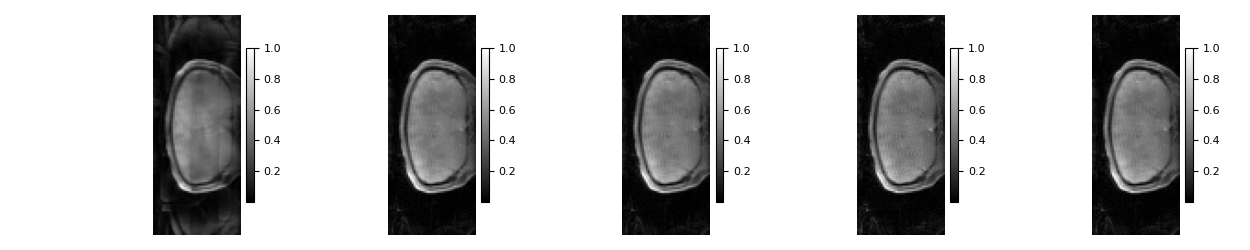

interactive(children=(IntSlider(value=0, description='r', max=1), IntSlider(value=0, description='p', max=35),…

In [ ]:
# Evaluate Recons (few ROs_CAIP12) images from h5 file 
import numpy as np
import h5py 

sagital=True

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'

# Rep=0 #selected partition 
data=[]
titles=[]

RO_start=30
RO_end=66


#SENSE recon ( )
imgs=[]
file='CEST_APT_C12/' \
'CEST_SENSE_recons_Reps_0_2_r_0.01_i_5_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


#SENSE recon ( )
imgs=[]
file='CEST_APT_C12/' \
'CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

#SENSE recon ( )
imgs=[]
file='CEST_APT_C12/' \
'CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


#SENSE recon ( )
imgs=[]
file='CEST_APT_C12/' \
'CEST_SENSE_recons_Reps_0_2_r_1e-200_i_100_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('r1e-200_i100')


#SENSE recon ( )
imgs=[]
file='CEST_APT_C12/' \
'CEST_SENSE_recons_Reps_0_2_r_1e-300_i_60_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('r1e-200_i100')


print('Data shape',np.shape(data))

if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))
plotgRP(data,cols=5)


SENSE recon shape after transpose: (2, 48, 120, 20)
SENSE recon shape after transpose: (2, 48, 120, 20)
SENSE recon shape after transpose: (2, 48, 120, 20)
SENSE recon shape after transpose: (2, 48, 120, 20)
SENSE recon shape after transpose: (2, 48, 120, 20)


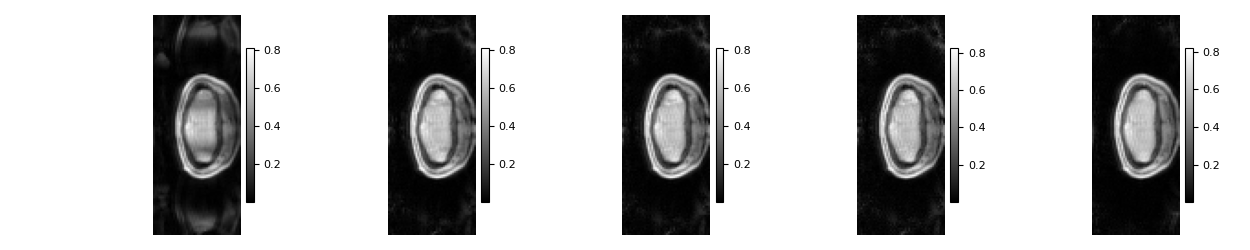

interactive(children=(IntSlider(value=0, description='r', max=1), IntSlider(value=0, description='p', max=19),…

In [ ]:
# Evaluate Recons (few ROs_CAIP6) images from h5 file 
import numpy as np
import h5py 

sagital=True

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'

# Rep=0 #selected partition 
data=[]
titles=[]

#SENSE recon ( )
imgs=[]
RO_start=16
RO_end=36



file='CEST_APT_C6/CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_Hyb.h5'
imgs=[]

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


file='CEST_APT_C6/CEST_SENSE_recons_Reps_0_2_r_1e-10' \
'_i_30_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_Hyb.h5'
imgs=[]

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


# file='CEST_APT_C6/CEST_SENSE_recons_Reps_0_2_r_1e-10' \
# '_i_10_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_Hyb.h5'
# imgs=[]

# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# # imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
# print('SENSE recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(imgs)) 
# titles.append('SENSE recon')



file='CEST_APT_C6/CEST_SENSE_recons_Reps_0_2_r_1e-10' \
'_i_50_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_Hyb.h5'
imgs=[]

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')



file='CEST_APT_C6/CEST_SENSE_recons_Reps_0_2_r_1e-10' \
'_i_80_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_Hyb.h5'
imgs=[]

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


file='CEST_APT_C6/' \
'CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
imgs=[]

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))
plotgRP(data,cols=5)


In [49]:
# #Dicom images 
# from pydicom import dcmread

# file_dcm='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C6/1.dcm'

# dcm=dcmread(file_dcm).pixel_array
# print(np.shape(dcm))
# # img_dcm=dcm[36,...]
# dcm=rot(dcm)
# plotw(dcm,rotate=False,vmax=abs(np.max(dcm)))

# # import h5py
# # with h5py.File('/home/vault/iwbi/iwbi112h/CEST_Data/CEST_WM_dicom.h5','w') as f:
# #     f.create_dataset('dcm_Rep_8', data=dcm, chunks=(1, dcm.shape[1], 1))

(48, 120, 120)
org DCM: min 0,max 1335, mean 159.28140914351852
mod DCM: min 0.0,max 1.0, mean 0.1193119169614371
SENSE recon shape after transpose: (2, 48, 120, 112)
SENSE recon shape after transpose: (2, 48, 120, 112)
original SENSE Recon:min 4.658059182816032e-08,max 0.0017033525509759784, mean 0.00016811524983495474
mod SENSE Recon:min 2.7346419301466085e-05,max 1.0, mean 0.09869672358036041
SENSE recon shape after transpose: (2, 48, 120, 112)


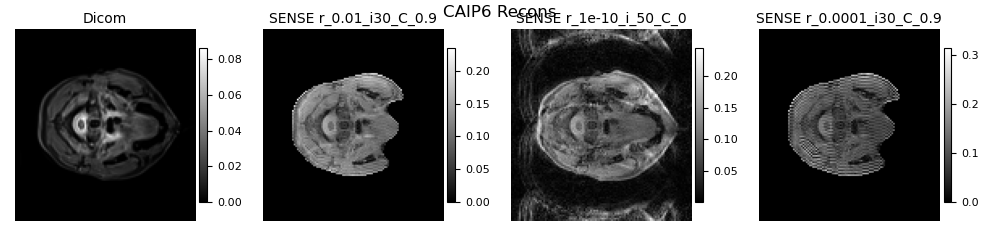

interactive(children=(IntSlider(value=0, description='r', max=0), IntSlider(value=0, description='p', max=47),…

In [11]:
#View Recon images (CAIP 6) from h5 file 
import numpy as np
import h5py 
from skimage import exposure 

RO_start=0
RO_end=112

sagital=False

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C6/'


# Rep=0 #selected partition 
data=[]
titles=[]
#Dicom images 
from pydicom import dcmread

file='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C6/1.dcm'

dcm=dcmread(file)

dcm=dcm.pixel_array
print(np.shape(dcm))
# img_dcm=dcm[36,...]
dcm=rot(abs(dcm),part=True, roll_part=True)
print(f'org DCM: min {dcm.min()},max {dcm.max()}, mean {dcm.mean()}')
dcm=dcm/(np.max(dcm))
dcm_c6=dcm.copy()
print(f'mod DCM: min {dcm.min()},max {dcm.max()}, mean {dcm.mean()}')
dcm_mean=dcm.mean()
dcm=np.power(dcm,1/.5)
data.append([dcm]) 
titles.append('Dicom')
del dcm 


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C6_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C6.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r_0.01_i30_C_0.9')

imgs_c6=imgs.copy()/imgs.max()

#SENSE recon ( )
imgs=[]
# file='CEST_SENSE_recons_Reps_0_26_r_0.01_i_30_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# file='CEST_SENSE_recons_Reps_0_26_r_0.08_i_30_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=abs(np.asarray(imgs))
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
print(f'original SENSE Recon:min {imgs.min()},max {imgs.max()}, mean {imgs.mean()}')

imgs=imgs/(imgs.max())
print(f'mod SENSE Recon:min {imgs.min()},max {imgs.max()}, mean {imgs.mean()}')
data.append(imgs) 
titles.append('SENSE r_1e-10_i_50_C_0')
#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.0001_i_30_kdat_2D_R26_C58_C6_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C6.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r_0.0001_i30_C_0.9')

if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))
plotgRP(data,titles=titles,cols=4,subtitle='CAIP6 Recons')


In [80]:
# #Histogram comparison to see pixel distributions

# # import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats

# # Assuming your DICOM data is in range [0,1]
# dicom_flat = dcm.flatten()
# sense_flat = sense.flatten()

# # Sample to avoid memory issues
# sample_size = min(100000, len(dicom_flat))
# dicom_sample = np.random.choice(dicom_flat, sample_size, replace=False)
# sense_sample = np.random.choice(sense_flat, sample_size, replace=False)

# # Plot histograms to see the stretching
# plt.figure(figsize=(12,5))

# plt.subplot(121)
# plt.hist(dicom_sample, bins=100, alpha=0.7, label='DICOM', density=True)
# plt.hist(sense_sample, bins=100, alpha=0.7, label='SENSE', density=True)
# plt.xlabel('Pixel Value')
# plt.ylabel('Density')
# plt.title('Histogram Comparison')
# plt.legend()
# plt.yscale('log')

# plt.subplot(122)
# # Cumulative distribution
# plt.plot(np.sort(dicom_sample), np.linspace(0, 1, len(dicom_sample)), label='DICOM')
# plt.plot(np.sort(sense_sample), np.linspace(0, 1, len(sense_sample)), label='SENSE')
# plt.xlabel('Pixel Value')
# plt.ylabel('CDF')
# plt.title('Cumulative Distribution')
# plt.legend()
# plt.grid(True)

# plt.show()

In [13]:
#View Recon images (CAIP12) from h5 file 
import numpy as np
import h5py 

sagital=False

RO_start=0
RO_end=114

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C12/'
# Rep=0 #selected partition 
data=[]
titles=[]
#Dicom images 
from pydicom import dcmread

file='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C12/1.dcm'

dcm=abs(dcmread(file).pixel_array)
print(np.shape(dcm))
# img_dcm=dcm[36,...]
dcm=rot(abs(dcm),part=True, roll_part=True)
# dcm= np.power(np.abs(dcm),1.4)
# dcm= (dcm - dcm.min()) / (dcm.max() - dcm.min())
dcm=dcm/np.max(dcm)
data.append([abs(dcm)]) 
titles.append('Dicom')
dcm_c12=dcm.copy()
del dcm 


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r0.01_i30_C0.9')
imgs_c12=imgs.copy()/imgs.max()


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_100_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r0.01_i100_C0.9')
imgs_c12=imgs.copy()/imgs.max()


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# 'CEST_SENSE_recons_Reps_0_2_r_1e-200_i_100_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# 'CEST_SENSE_recons_Reps_0_2_r_1e-10_i_50_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C12_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r1e-10_i50_C0')


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-10_i_30_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r1e-10_i30_C0.9')



#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.08_i_30_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r0.08_i30_C0.9')


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-15_i_30_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r1e-15_i30_C0.9')



#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-15_i_60_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE r1e-15_i60_C0.9')



#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C6_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C6.h5'

with h5py.File('/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C6/'+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('CAIP6 r_0.01_i30_C_0.9')



#diff img ( )

data.append((imgs_c12[...,0:112]-imgs_c6)) 
titles.append('CAIP12_CAIP6 diff')


#diff dcm img ( )
# dcm_dif=[dcm_c12[i,...]-dcm_c6[i,...] for i in range(48)]
dcm_dif=dcm_c12-dcm_c6
print('dcm_diff shape',dcm_dif.shape)
data.append([dcm_dif]) 
titles.append('dcm12_dcm6 diff')




if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))

# print('Data shape',data.shape)

plotgRP(data,cols=6,subtitle='CAIP12 Recons',titles=titles)


(48, 120, 120)
SENSE recon shape after transpose: (2, 48, 120, 114)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C12/CEST_SENSE_recons_Reps_0_2_r_0.01_i_100_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C12.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

SENSE recon shape after transpose: (2, 48, 120, 120)
SENSE recon shape after transpose: (2, 48, 120, 120)
SENSE recon shape after transpose: (2, 48, 120, 120)


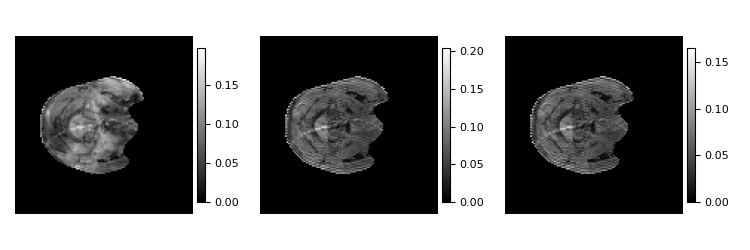

interactive(children=(IntSlider(value=0, description='r', max=1), IntSlider(value=0, description='p', max=47),…

In [20]:
#View Recon images (CAIP16) from h5 file 
import numpy as np
import h5py 

sagital=False

RO_start=0
RO_end=120

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/CEST_APT_C16/'

# Rep=0 #selected partition 
data=[]
titles=[]

#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R26_C58_C16_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C16.h5'


with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')


#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-05_i_30_kdat_2D_R26_C58_C16_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C16.h5'


with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')



#SENSE recon ( )
imgs=[]
file='CEST_SENSE_recons_Reps_0_2_r_1e-10_i_30_kdat_2D_R26_C58_C16_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C16.h5'


with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')



if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))
plotgRP(data,cols=3)


SENSE recon shape after transpose: (2, 28, 96, 114)
SENSE recon shape after transpose: (2, 28, 96, 114)
SENSE recon shape after transpose: (2, 28, 96, 114)
SENSE recon shape after transpose: (2, 28, 96, 114)
Data shape (4, 2, 28, 96, 114)


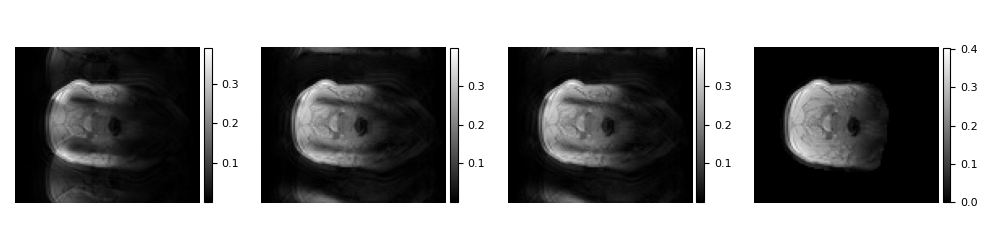

interactive(children=(IntSlider(value=0, description='r', max=1), IntSlider(value=0, description='p', max=27),…

In [12]:
#View Recon images (GRAPPA3) from h5 file 
import numpy as np
import h5py 

sagital=False

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'

# Rep=0 #selected partition 
data=[]
titles=[]

#SENSE recon ( )
imgs=[]

file='/CEST_GRAPPA3/' \
'CEST_SENSE_recons_Reps_0_2_r_0.01_i_2_kdat_2D_R34_C52_GRAPPA3_mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

#SENSE recon ( )
imgs=[]

file='/CEST_GRAPPA3/' \
'CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R34_C52_GRAPPA3_mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

#SENSE recon ( )
imgs=[]

file='/CEST_GRAPPA3/' \
'CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R34_C52_GRAPPA3_mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3_2.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

#SENSE recon ( )
imgs=[]

file='/CEST_GRAPPA3/' \
'CEST_SENSE_recons_Reps_0_2_r_0.01_i_30_kdat_2D_R34_C52_GRAPPA3_mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for Sagital view 
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(abs(imgs)) 
titles.append('SENSE recon')

print('Data shape',np.shape(data))

if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))
plotgRP(data,cols=4)


<KeysViewHDF5 ['mps']>
mps shape (52, 28, 96, 114)
mps rss shape (52, 28, 96, 114)
data shape (1, 52, 28, 96, 114)


interactive(children=(IntSlider(value=0, description='r', max=51), IntSlider(value=0, description='p', max=27)…

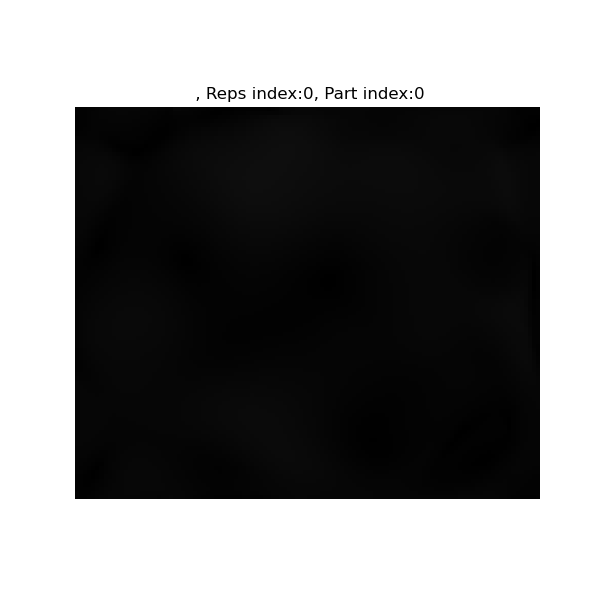

In [12]:
#view mps from h5 files 
import numpy as np
import h5py
import sigpy as sp

sagital=False

# Rep=0 #selected partition 
data=[]
titles=[]

#mps images 
imgs=[]
# file='CEST_APT_C12/kdat_3D_R26_C58_CAIP12.h5'
# file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_CAIP12.h5'
# file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_CAIP12.h5'
# file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0_t0.05_w_24_kw_6_sp_Hyb_3D_R26_C58_C6.h5'
# file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_C6.h5'
file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3.h5'
with h5py.File( file,'r')as f:
    print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)

    imgs=f['mps'][:]

print('mps shape',imgs.shape)

# imgs=np.transpose(imgs,(-4,-1,-2,-3)) # uncomment for sagital view 
# imgs=sp.rss(imgs,axes=0) # uncomment for magnitude image
print('mps rss shape',imgs.shape)

data.append(imgs)
titles.append('mps')



del imgs

print('data shape',np.array(data).shape)

if sagital:
    data[0]=np.transpose(data[0],(-4,-1,-2,-3))
plotRP(data[0],titles= None)

del data


<KeysViewHDF5 ['refs']>
ref shape before zp (52, 28, 96, 114)
ref shape (52, 28, 96, 114)
<KeysViewHDF5 ['mps']>
mps shape (52, 28, 96, 114)
data shape (2, 52, 114, 96, 28)


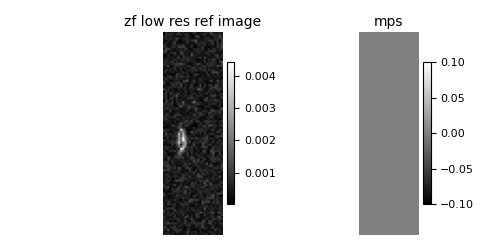

interactive(children=(IntSlider(value=0, description='r', max=51), IntSlider(value=0, description='p', max=113…

In [15]:
#view imgs from h5 files (zf ref + mps )
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'

sagital=True
# Rep=0 #selected partition 
data=[]
titles=[]

#zf ref images 
imgs=[]
file='/CEST_GRAPPA3/' \
'ACS_3D_C52_2.h5'

# file='CEST_APT_C12/kdat_3D_R26_C58_CAIP12.h5'
# file='CEST_APT_C16/kdat_3D_R26_C58_CAIP16.h5'
with h5py.File(DATA_DIR + file,'r')as f:
    print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    try:
        imgs=f['ref'][:]
        imgs=sp.resize(imgs,(58,48,120,120))
        # imgs=sp.resize(imgs,(58,48,120,240))
    except KeyError:
        imgs=f['refs'][:]
print('ref shape before zp',imgs.shape)

imgs=sp.ifft(imgs,axes=(-3,-2,-1))
print('ref shape',imgs.shape)

data.append(imgs)
titles.append('zf low res ref image')


#mps images 
imgs=[]
# file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0_t0.05_w_48_kw_6_sp_Hyb_3D_R26_C58_C6.h5'
file='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/mps_c_0.9_t0.05_w_24_kw_6_sp_ksp_3D_R34_C52_GRAPPA3.h5'
with h5py.File( file,'r')as f:
    print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)

    imgs=f['mps'][:]

print('mps shape',imgs.shape)


data.append(imgs)
titles.append('mps')
del imgs

if sagital:
    # data[0]=np.transpose(data[0],(-4,-1,-2,-3))
    data=np.transpose(data,(-5,-4,-1,-2,-3))

print ('data shape',np.array(data).shape)

plotgRP(data,cols=2,titles= titles)

del data


In [21]:
# #view  maps (separate ACS data)

# import torch 
# import numpy as np
# import h5py
# import sigpy as sp

# DATA_DIR='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/'
# file='mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_CAIP12.h5'
# data=[]
# titles=[]
# part=slice(None)
# # part=20

# imgs=[]
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:6, t:0.05, CAIP12')
# print('mps shape',imgs.shape)


# imgs=[]
# file='mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R26_C58_CAIP16.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:6, t:0.05, CAIP16')
# print('mps shape',imgs.shape)

# len(data)
# # plotg(data,cols=4,titles=titles)
# plotgRP(data,cols=2,titles=titles)

# del data
# del imgs
# gc.collect()

In [ ]:
#exploring ACS data and recon images for NaNs
imgs=[]
# imgs_2=[]
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x1x1_r_0.01_i_1_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.025_w_24_kw_6_sp_ksp.h5'
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x2x2_r_0.01_i_5_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_0.8_1shot.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.array(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

# imgs.shape
# np.isnan(imgs).sum()
import matplotlib.pyplot as plt

# Look at Slice 5, Coil 0
plt.figure()
plt.imshow(np.isnan(imgs[1, 1, :, :]), cmap='gray')
plt.title("White pixels = NaNs")
plt.show()

grappa recon shape: torch.Size([34, 24, 96, 114])
grappa recon shape: (34, 24, 96, 114)


/tmp/ipykernel_4120171/1855003136.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  volume=np.array(volume)


SENSE recon shape after transpose: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)
ACS imgs shape: (24, 96, 114)
ACS shape after repeat: (34, 24, 96, 114)
<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)


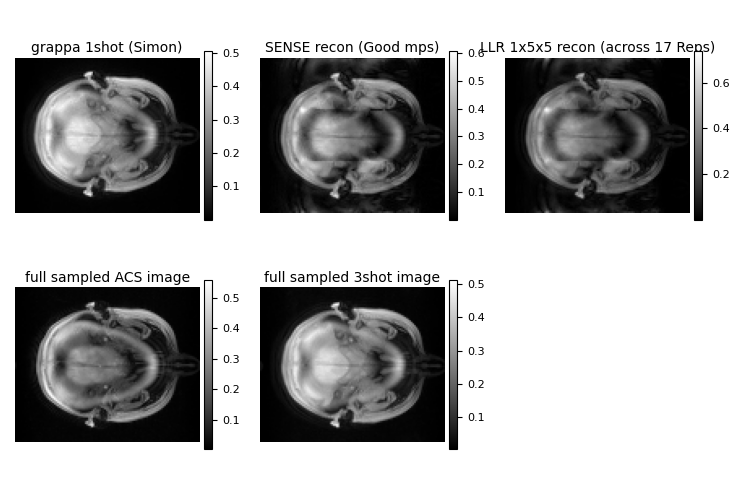

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

In [24]:
#view imgs recon by Simon (1shot || Cart us factor = 3)
import torch 
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

# Rep=0 #selected partition 
data=[]
titles=[]

#simon images
file='imgs_grappa_1shot.pth'
# file='imgs_3shot.pth'
imgs=torch.load(DATA_DIR+file)
imgs=np.permute_dims(imgs,(0,3,2,1))
print('grappa recon shape:',imgs.shape)
imgs=rot(imgs,part=True,flip=False,k=-2)
imgs=np.roll(imgs,shift=1,axis=-3)
print('grappa recon shape:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(imgs)
titles.append('grappa 1shot (Simon)')


# with h5py.File(DATA_DIR+'imgs_grappa_1shot_simon.h5','w') as f:
# with h5py.File(DATA_DIR+'imgs_3shot_simon.h5','w') as f:
#     f.create_dataset('imgs',data=imgs)


# #SENSE recon (poor mps)
# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.02_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon (poor mps)')

# #SENSE recon (PE:96)
# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_96.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon ( PE1:96)')

#SENSE recon (good mps)
imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(imgs)
titles.append('SENSE recon (Good mps)')

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(imgs)
titles.append('LLR 1x5x5 recon (across 17 Reps)')
del imgs, imgs_2

# #LLR recon (over 34 Reps)
# imgs=[]
# file='CEST_LLR_recons_Reps_0_34_RO_0_114_1x5x5_r_1e-06_i_30_2D_kdat_3D_R34_C44_1shot_mps_0.8_1shot.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # keys=list(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.array(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('LLR recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('LLR 1x5x5 recon (across 34 Reps)')


imgs=[]
## fully sampled ACS images
file='ACS_3D_C44_1shot_ifft_imgs.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    imgs=f['imgs'][:]
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('ACS imgs shape:',imgs.shape)
imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
print('ACS shape after repeat:',imgs.shape)

data.append(imgs)
titles.append('full sampled ACS image')

## fully sampled ACS images
imgs=[]
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append((imgs))
titles.append('full sampled 3shot image')

del imgs

# plotg(data,cols=3,titles=titles)
plotgRP(data,cols=3,titles=titles,phase=False)
del data

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

LLR recon shape after concatenation: (34, 24, 96, 114)



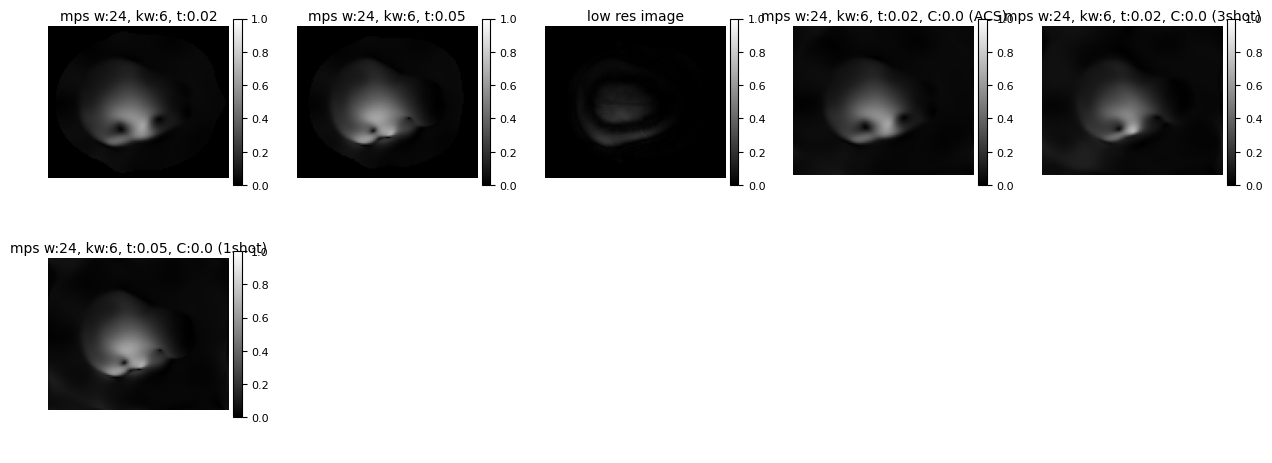

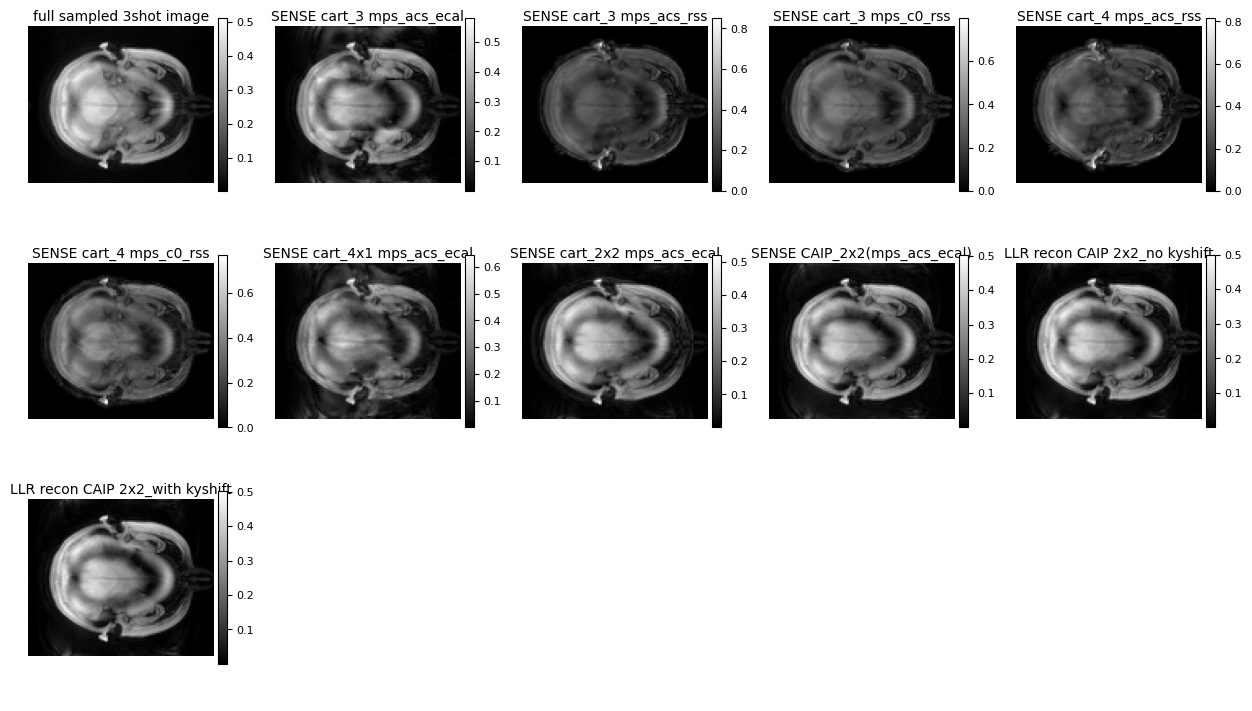

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

In [14]:
#view retro US images (3SHOTS)
import h5py
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

data=[]
titles=[]


imgs=[]
## fully sampled ACS images
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append(abs(imgs))
titles.append('full sampled 3shot image')

# #simon images
# file='imgs_grappa_1shot.pth'
# # file='imgs_3shot.pth'
# imgs=torch.load(DATA_DIR+file)
# imgs=np.permute_dims(imgs,(0,3,2,1))
# print('grappa recon shape:',imgs.shape)
# imgs=rot(imgs,part=True,flip=False,k=-2)
# imgs=np.roll(imgs,shift=1,axis=-3)
# # data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(imgs)) 
# titles.append('grappa 1shot (Simon)')



imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_acs_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_c0_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4 mps_acs_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4 mps_c0_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_Cart_4x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'


RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4x1 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_Cart_2x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_2x2 mps_acs_ecal')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_6_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_6_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_8_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_8_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_10_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_10_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_12_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_12_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE us_CAIP_2x2(ACS mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE us_CAIP_2x2(CEST mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_CEST_mps.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE CAIP_2x2(mps_c0_ecal)')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_CAIP_2x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE CAIP_2x2(mps_acs_ecal)')




# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE CAIP_3x2 mps_acs_ecal ')


#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(imgs)) 
titles.append('LLR recon CAIP 2x2_no kyshift')
del imgs, imgs_2

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(imgs)) 
titles.append('LLR recon CAIP 2x2_with kyshift')
del imgs, imgs_2




plotgRP(data,titles=titles,cols=5)
# plotgp(data[None,...],titles=titles,)
# data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(imgs)) 
# titles.append('SENSE recon (poor mps)')
del data

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)


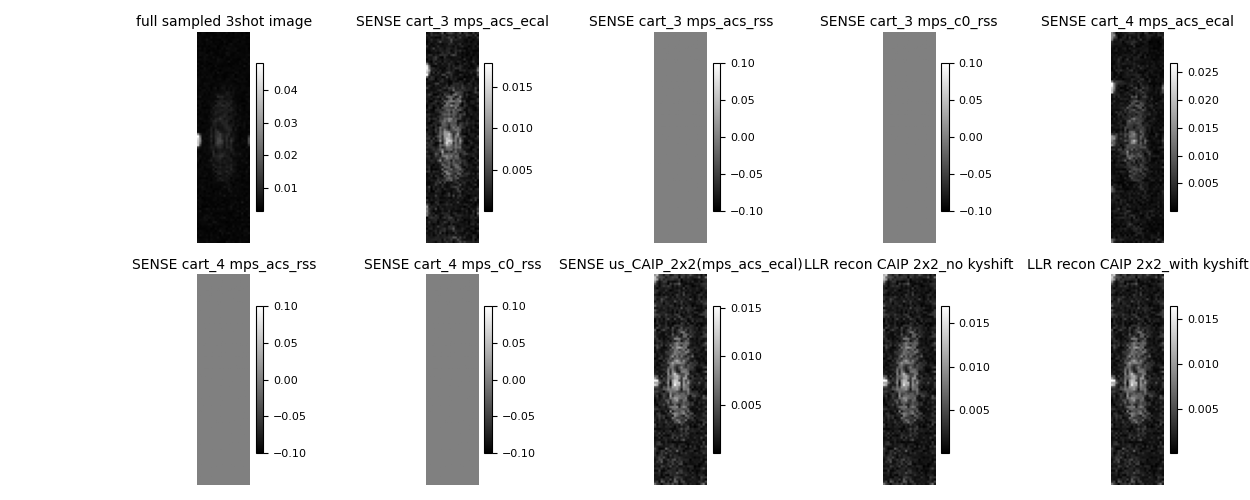

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=113…

In [ ]:
#view retro US images _sagitals
import h5py
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

sag_dims=(-4,-1,-2,-3)

data=[]
titles=[]


imgs=[]
## fully sampled ACS images
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('full sampled 3shot image')

# #simon images
# file='imgs_grappa_1shot.pth'
# # file='imgs_3shot.pth'
# imgs=torch.load(DATA_DIR+file)
# imgs=np.permute_dims(imgs,(0,3,2,1))
# print('grappa recon shape:',imgs.shape)
# imgs=rot(imgs,part=True,flip=False,k=-2)
# imgs=np.roll(imgs,shift=1,axis=-3)
# # data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(np.transpose(imgs,axes=sag_dims))) 
# titles.append('grappa 1shot (Simon)')



imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_acs_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_c0_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_acs_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_c0_rss')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_6_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_6_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_8_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_8_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_10_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_10_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_12_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_12_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE us_CAIP_2x2(ACS mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE us_CAIP_2x2(CEST mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_CEST_mps.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE CAIP_2x2(mps_c0_ecal)')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE us_CAIP_2x2(mps_acs_ecal)')




# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE CAIP_3x2 mps_acs_ecal ')


#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(np.transpose(imgs,axes=sag_dims))) 
titles.append('LLR recon CAIP 2x2_no kyshift')
del imgs, imgs_2

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(np.transpose(imgs,axes=sag_dims))) 
titles.append('LLR recon CAIP 2x2_with kyshift')
del imgs, imgs_2




plotgRP(data,titles=titles,cols=5)
# plotgp(data[None,...],titles=titles,)
# data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(np.transpose(imgs,axes=sag_dims))) 
# titles.append('SENSE recon (poor mps)')
del data

(70, 448, 360)


interactive(children=(IntSlider(value=0, description='i', max=69), FloatSlider(value=0.0, description='Min (Bl…

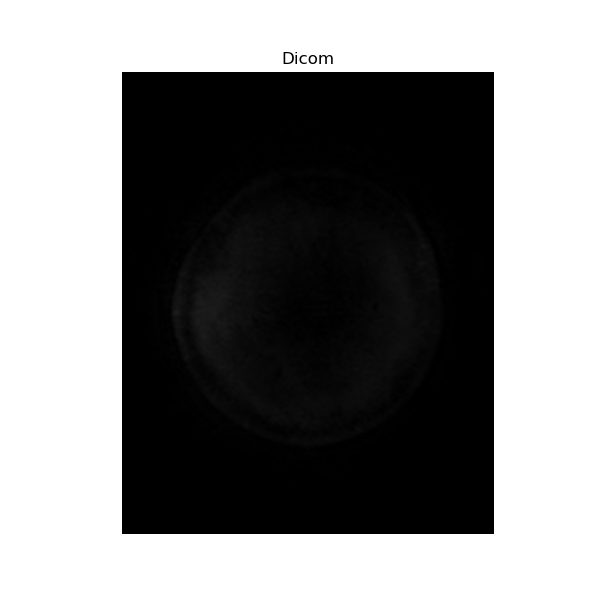

In [ ]:
#Dicom images 
from pydicom import dcmread

file_dcm='/home/hpc/iwbi/iwbi112h/LLR_Daten/HighResMelon/dicom/100_wip_Snap_Cai_4_3_1-1-2_1p00_53_MR/9.dcm'

dcm=dcmread(file_dcm).pixel_array
print(np.shape(dcm))
img_dcm=dcm[36,...]
plotw(dcm,'Dicom',rotate=False,vmax=abs(np.max(img_dcm)))

# import h5py
# with h5py.File('/home/vault/iwbi/iwbi112h/CEST_Data/CEST_WM_dicom.h5','w') as f:
#     f.create_dataset('dcm_Rep_8', data=dcm, chunks=(1, dcm.shape[1], 1))

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
imgs shape before concat: [(17, 24, 96, 114), (17, 24, 96, 114)]
imgs shape: (34, 24, 96, 114)
orignal dyn. range: 2.623388581923791e-06 - 0.001043512369506061 
imgs shape: (34, 24, 96, 114)


interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

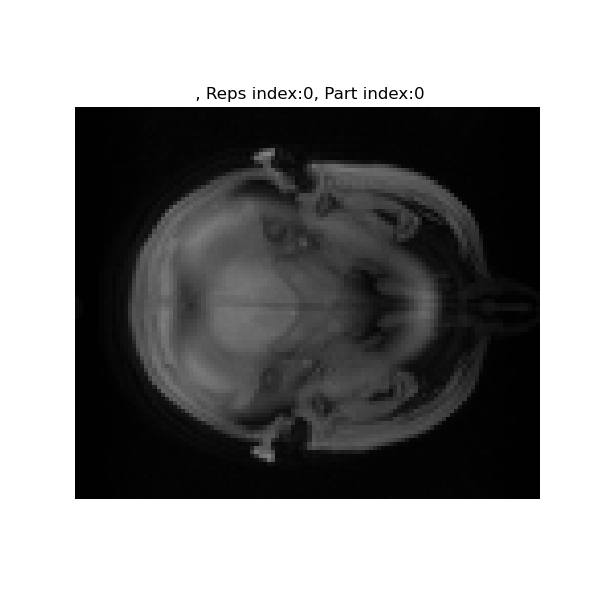

In [ ]:
#3shot ifft recon 
import h5py
import numpy as np

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'
# file='CEST_GRAPPA_recons_65.h5' # clipped grappa for 65 Reps 
file='ifft_recon_3shot.h5'
imgs=[]
data_keys = ['kdat_01','kdat_02']

with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    for data in data_keys:
        imgs.append(f[data][:])

# min_val=np.min(abs(np.array(imgs)))
# max_val=np.max(abs(np.array(imgs)))
print('imgs shape before concat:',[img.shape for img in imgs])
imgs=np.array(imgs)
imgs=np.concatenate(imgs,axis=0)
print('imgs shape:',imgs.shape)
print(f'orignal dyn. range: {np.min(abs(imgs))} - {np.max(abs(imgs))} ')
# imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)
# plotw(imgs,min_val=min_val,max_val=max_val)
# plotw(imgs,'GRAPPA',dynasdcm=False, norm=True )
plotRP(imgs)
# img_g=imgs[36,...]